# DISEASE → POVERTY: Visualisation

Detailed visualisation of the DISEASE→POVERTY conceptual metaphor mapping
from the LCC corpus: kernel heatmaps, sparse network graphs, and permutation null distributions.

In [23]:
# Configuration
# Set the source and target concept labels here.
# Labels must match CMSourceAnnotation sourceConcept / targetConcept values
# in the LCC corpus (case-sensitive, e.g. 'DISEASE', 'POVERTY').

SOURCE_CONCEPT = "PHYSICAL_HARM"
TARGET_CONCEPT = "BUREAUCRACY"

EDGE_FRACTION = 0.20  # keep top X fraction of edges (e.g. 0.20 = top 20%)
N_PERMS  = 1000   # permutation test iterations


In [24]:
from pathlib import Path
from collections import defaultdict
import numpy as np

from intrarepresentational_alignment.data import load_lcc
from intrarepresentational_alignment.embedding import Embedder
from intrarepresentational_alignment.models import EmbeddingModel
from intrarepresentational_alignment.similarity import CosineSimilarity, SparseKernel
from intrarepresentational_alignment.graph import TopFraction
from intrarepresentational_alignment.alignment import cka_permutation_test, ged_permutation_test

LCC_PATH = Path("data/en_small.xml")
instances = load_lcc(LCC_PATH)
annotated = [i for i in instances if i.source_concept and i.source_concept != "OTHER"]

domain_pairs: dict[tuple, list[tuple]] = defaultdict(list)
for inst in annotated:
    for s in inst.source_expressions:
        for t in inst.target_expressions:
            domain_pairs[(inst.source_concept, inst.target_concept)].append((s, t))

KEY = (SOURCE_CONCEPT, TARGET_CONCEPT)
if KEY not in domain_pairs:
    available = sorted(domain_pairs, key=lambda k: len(domain_pairs[k]), reverse=True)
    raise ValueError(
        f'No pairs found for {SOURCE_CONCEPT!r} -> {TARGET_CONCEPT!r}.\n'
        f'Top available pairs: {available[:10]}'
    )

pairs     = domain_pairs[KEY]
src_texts = [s for s, _ in pairs]
tgt_texts = [t for _, t in pairs]
print(f'{SOURCE_CONCEPT} -> {TARGET_CONCEPT}: {len(pairs)} expression pairs')

embedder   = Embedder(EmbeddingModel.ALL_MINILM_L6_V2)
S          = embedder.embed(src_texts)
T          = embedder.embed(tgt_texts)
K_S_dense  = S @ S.T
K_T_dense  = T @ T.T

sparse     = SparseKernel(CosineSimilarity(), TopFraction(EDGE_FRACTION))
K_S_sparse = sparse.matrix(S)
K_T_sparse = sparse.matrix(T)

rng     = np.random.default_rng(42)
cka_res = cka_permutation_test(K_S_dense, K_T_dense, n_permutations=N_PERMS, rng=rng)
rng     = np.random.default_rng(42)
ged_res = ged_permutation_test(K_S_dense, K_T_dense, n_permutations=N_PERMS, rng=rng)

print(f'CKA = {cka_res.observed:.3f}  (p = {cka_res.p_value:.3f})')
print(f'GED = {ged_res.observed:.3f}  (p = {ged_res.p_value:.3f})')


PHYSICAL_HARM -> BUREAUCRACY: 8 expression pairs
CKA = 0.825  (p = 0.010)
GED = 0.194  (p = 0.007)


## Kernel matrices: before and after pruning

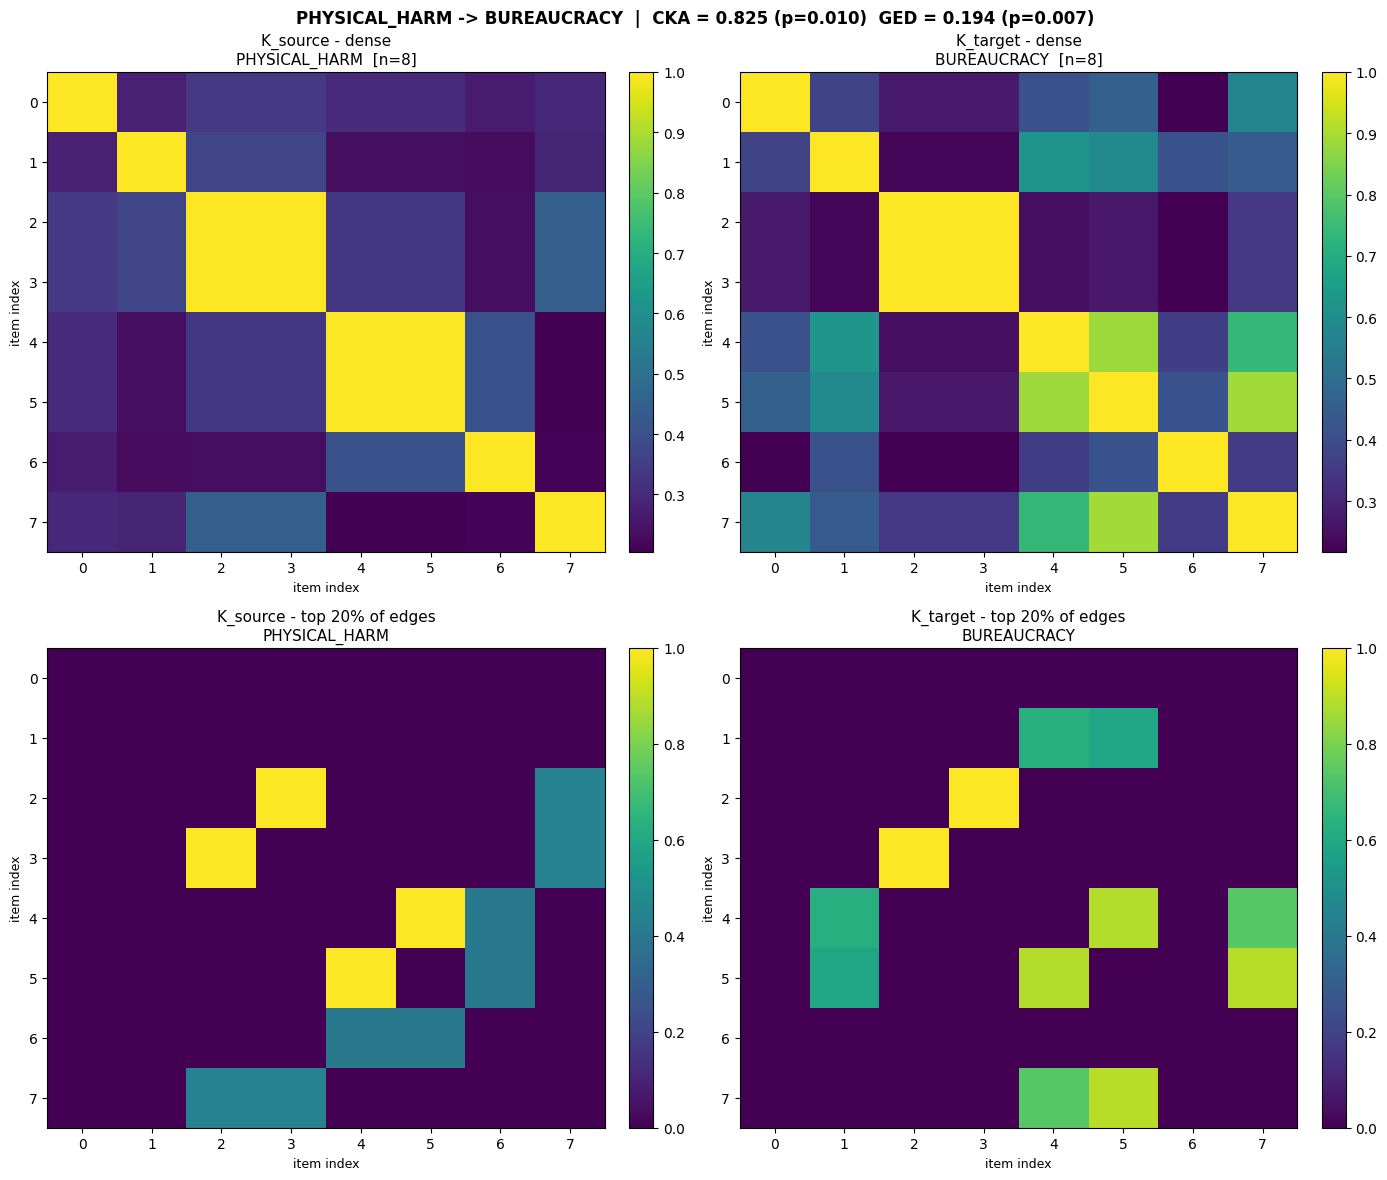

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

def heat(ax, M, title, vmin=None, vmax=None):
    im = ax.imshow(M, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xlabel('item index', fontsize=9)
    ax.set_ylabel('item index', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

n = len(pairs)
heat(axes[0, 0], K_S_dense,  f'K_source - dense\n{SOURCE_CONCEPT}  [n={n}]')
heat(axes[0, 1], K_T_dense,  f'K_target - dense\n{TARGET_CONCEPT}  [n={n}]')
heat(axes[1, 0], K_S_sparse, f'K_source - top {int(EDGE_FRACTION*100)}% of edges\n{SOURCE_CONCEPT}', vmin=0)
heat(axes[1, 1], K_T_sparse, f'K_target - top {int(EDGE_FRACTION*100)}% of edges\n{TARGET_CONCEPT}', vmin=0)

fig.suptitle(
    f'{SOURCE_CONCEPT} -> {TARGET_CONCEPT}  |  CKA = {cka_res.observed:.3f} (p={cka_res.p_value:.3f})'
    f'  GED = {ged_res.observed:.3f} (p={ged_res.p_value:.3f})',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()


## Network graphs (mutual-KNN k=5)

Nodes are individual expressions; edges connect mutual nearest neighbours weighted by cosine similarity.

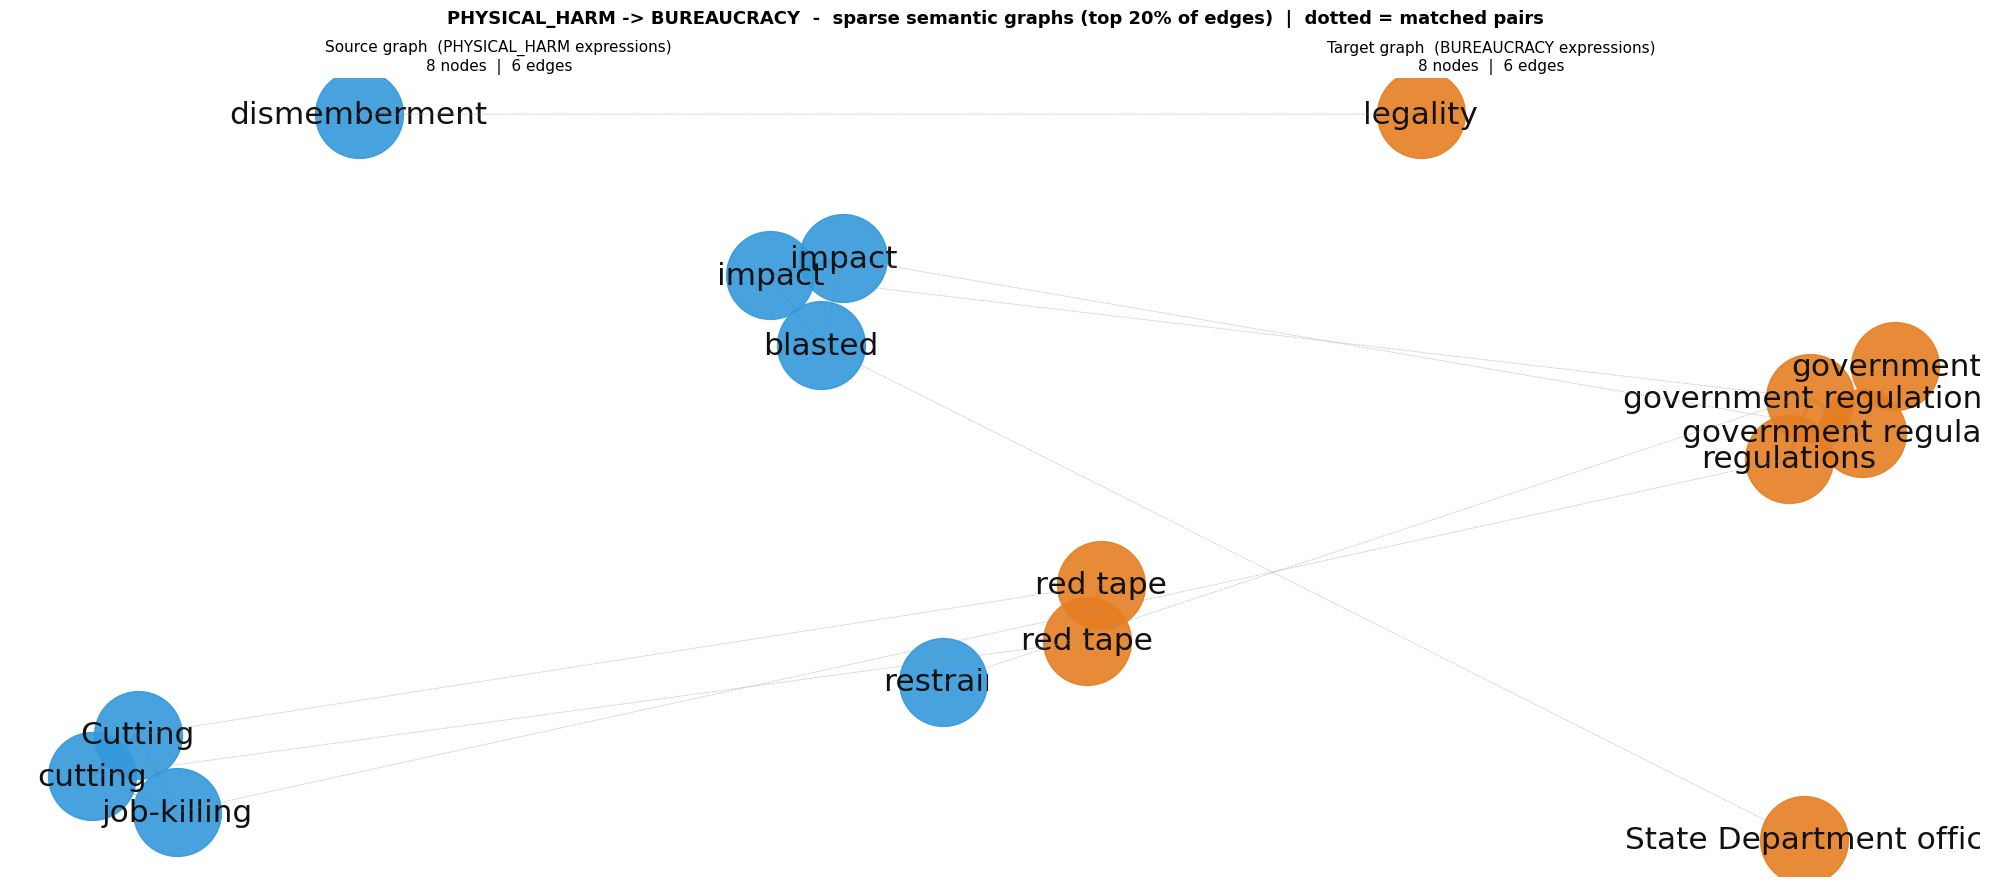

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

def adj_to_graph(adj):
    G = nx.Graph()
    G.add_nodes_from(range(adj.shape[0]))
    for i in range(adj.shape[0]):
        for j in range(i + 1, adj.shape[0]):
            w = adj[i, j]
            if w > 0:
                G.add_edge(i, j, weight=float(w))
    return G

def draw_graph(ax, G, labels, title, node_color):
    pos = nx.spring_layout(G, seed=42, weight="weight")
    weights = np.array([G[u][v]["weight"] for u, v in G.edges()]) if G.edges() else np.array([])
    w_scaled = (0.5 + 3.5 * (weights - weights.min()) / (weights.max() - weights.min() + 1e-9)).tolist() if len(weights) else []
    nx.draw_networkx_edges(ax=ax, G=G, pos=pos, width=w_scaled, alpha=0.55, edge_color="#888888")
    nx.draw_networkx_nodes(ax=ax, G=G, pos=pos, node_size=4000, node_color=node_color, alpha=0.9)
    nx.draw_networkx_labels(ax=ax, G=G, pos=pos,
                            labels={i: labels[i][:22] for i in G.nodes()},
                            font_size=22.5, font_color="#111111")
    ax.set_title(f"""{title}
{G.number_of_nodes()} nodes  |  {G.number_of_edges()} edges""", fontsize=11)
    ax.axis("off")
    return pos

G_S = adj_to_graph(K_S_sparse)
G_T = adj_to_graph(K_T_sparse)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
pos_S = draw_graph(axes[0], G_S, src_texts, f"Source graph  ({SOURCE_CONCEPT} expressions)", "#3498db")
pos_T = draw_graph(axes[1], G_T, tgt_texts, f"Target graph  ({TARGET_CONCEPT} expressions)", "#e67e22")

# Dotted lines connecting each matched pair (i in S <-> i in T)
for i in range(len(pairs)):
    if i not in pos_S or i not in pos_T:
        continue
    con = mpatches.ConnectionPatch(
        xyA=pos_S[i], xyB=pos_T[i],
        coordsA=axes[0].transData, coordsB=axes[1].transData,
        linestyle="dotted",
        linewidth=0.7,
        color="#999999",
        alpha=0.5,
        clip_on=False,
    )
    fig.add_artist(con)

fig.suptitle(f"{SOURCE_CONCEPT} -> {TARGET_CONCEPT}  -  sparse semantic graphs (top {int(EDGE_FRACTION*100)}% of edges)  |  dotted = matched pairs",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Permutation null distributions

Grey histograms = CKA/GED scores under the null (pairs shuffled). Red line = observed score.

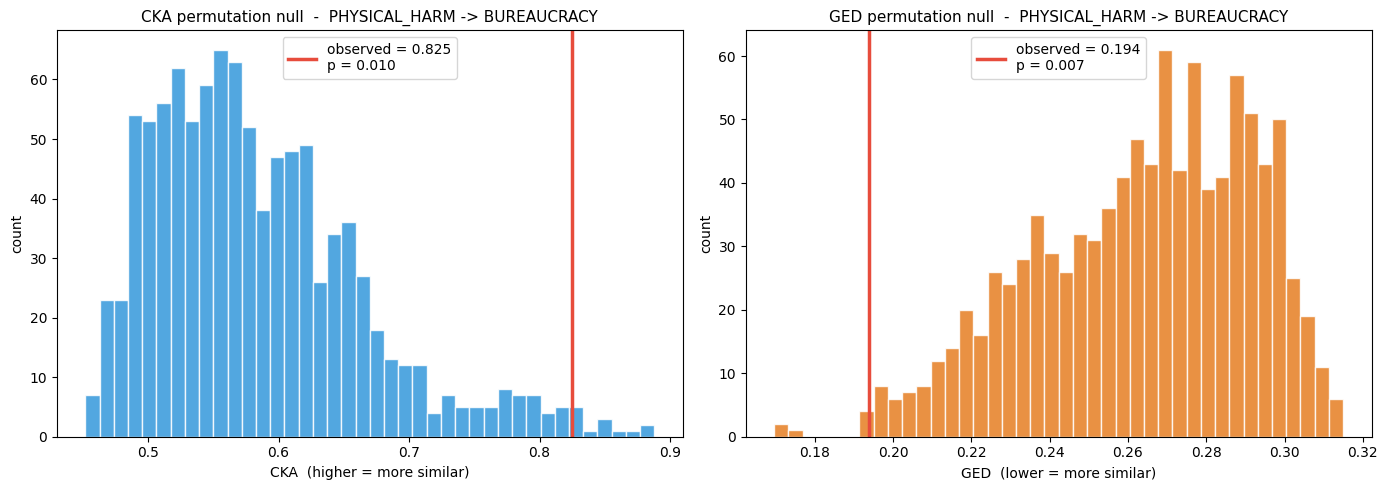

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(cka_res.null, bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(cka_res.observed, color='#e74c3c', linewidth=2.5,
                label=f'observed = {cka_res.observed:.3f}\np = {cka_res.p_value:.3f}')
axes[0].set_xlabel('CKA  (higher = more similar)', fontsize=10)
axes[0].set_ylabel('count', fontsize=10)
axes[0].set_title(f'CKA permutation null  -  {SOURCE_CONCEPT} -> {TARGET_CONCEPT}', fontsize=11)
axes[0].legend(fontsize=10)

axes[1].hist(ged_res.null, bins=40, color='#e67e22', edgecolor='white', alpha=0.85)
axes[1].axvline(ged_res.observed, color='#e74c3c', linewidth=2.5,
                label=f'observed = {ged_res.observed:.3f}\np = {ged_res.p_value:.3f}')
axes[1].set_xlabel('GED  (lower = more similar)', fontsize=10)
axes[1].set_ylabel('count', fontsize=10)
axes[1].set_title(f'GED permutation null  -  {SOURCE_CONCEPT} -> {TARGET_CONCEPT}', fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()
